# Building a Mini GPT from Scratch

SID4 = 1605, SEED = 1605.

This notebook builds a small GPT-style **decoder-only Transformer** in PyTorch and trains it on
`Shakespeare.txt` at the character level. It covers:

1. **Data preparation:** character-level tokenization and a sliding-window dataset (sequence length 128)
2. **GPT architecture:** multi-head masked self-attention written by hand, decoder blocks, and the full model
3. **Training:** Adam optimizer, 8 epochs, and a plot of training loss per epoch
4. **Sampling:** greedy, temperature, and top-k decoding from the prompt `"ROMEO:"`
5. **Analysis:** a comparison of the three decoding methods

Only basic building blocks are used (`nn.Linear`, `nn.LayerNorm`, `nn.GELU`, `nn.Embedding`, `nn.Dropout`).
**No** `nn.Transformer`, `nn.MultiheadAttention`, or HuggingFace models.

In [1]:
import math, time, json, random
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Reproducibility
SEED = 1605  # SID4
random.seed(SEED)
torch.manual_seed(SEED)

# Pick the fastest available device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


## Part 1: Data Preparation

### 1.1 Character-level tokenization
Every unique character in the corpus becomes one token. We build two lookup tables:
- `char_to_idx`: character → integer id (used to **encode**)
- `idx_to_char`: integer id → character (used to **decode**)

In [2]:
import os, urllib.request
DATA_PATH = "Shakespeare.txt"
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
if not os.path.exists(DATA_PATH):   # fall back to the public Tiny Shakespeare copy if the course file is absent
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

with open(DATA_PATH, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Corpus length: {len(text):,} characters")
print("-" * 40)
print(text[:250])

Corpus length: 1,115,394 characters
----------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



In [3]:
# Build the vocabulary from the sorted set of unique characters
chars = sorted(set(text))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

def encode(s: str) -> list[int]:
    """String -> list of token ids."""
    return [char_to_idx[c] for c in s]

def decode(ids) -> str:
    """List/tensor of token ids -> string."""
    return "".join(idx_to_char[int(i)] for i in ids)

print("Vocabulary size:", vocab_size)
print("Vocabulary:", repr("".join(chars)))

# Sanity check: encoding then decoding gives back the original text
sample = "ROMEO: But soft!"
assert decode(encode(sample)) == sample
print(f"encode({sample!r}) = {encode(sample)}")

Vocabulary size: 65
Vocabulary: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
encode('ROMEO: But soft!') = [30, 27, 25, 17, 27, 10, 1, 14, 59, 58, 1, 57, 53, 44, 58, 2]


### 1.2 Sliding-window dataset
With sequence length **T = 128**, each training example starts at a position `t`:

- **Input:** tokens `[t, t+1, ..., t+127]`
- **Target:** tokens `[t+1, ..., t+128]` (the input shifted one step left)

So at every position the model learns to predict the **next** character. The window slides across the
corpus with a configurable `stride`. With `stride=1` every possible window is used (about 1M nearly identical
windows). We use `stride=32`: each character still appears in 4 different windows (at different positions), and one epoch is about 490 steps.

We hold out the last 10% of the text as a validation set so we can check for overfitting.

In [4]:
SEQ_LEN = 128

class CharWindowDataset(Dataset):
    """Autoregressive (input, target) pairs made by sliding a window over the token stream."""

    def __init__(self, data: torch.Tensor, seq_len: int, stride: int = 1):
        self.data = data
        self.seq_len = seq_len
        # Window starts: we need seq_len + 1 tokens (input + one extra for the shifted target)
        self.starts = list(range(0, len(data) - seq_len - 1, stride))

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, i):
        t = self.starts[i]
        chunk = self.data[t : t + self.seq_len + 1]
        x = chunk[:-1]   # tokens t ... t+127
        y = chunk[1:]    # tokens t+1 ... t+128
        return x, y

data = torch.tensor(encode(text), dtype=torch.long)
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]

STRIDE = 32
train_ds = CharWindowDataset(train_data, SEQ_LEN, stride=STRIDE)
val_ds   = CharWindowDataset(val_data,   SEQ_LEN, stride=SEQ_LEN)  # non-overlapping windows for evaluation

print(f"Train tokens: {len(train_data):,} | Val tokens: {len(val_data):,}")
print(f"Train windows: {len(train_ds):,} | Val windows: {len(val_ds):,}")

Train tokens: 1,003,854 | Val tokens: 111,540
Train windows: 31,367 | Val windows: 871


In [5]:
# Show 2 example input-target pairs, decoded back to text
for n, i in enumerate([0, 1000]):
    x, y = train_ds[i]
    print(f"===== Example {n + 1} (window starting at token {train_ds.starts[i]}) =====")
    print(f"Input  ({len(x)} tokens):\n{decode(x)!r}\n")
    print(f"Target ({len(y)} tokens):\n{decode(y)!r}\n")
    print(f"First 5 (input -> target) pairs: "
          f"{[(decode([a]), decode([b])) for a, b in zip(x[:5], y[:5])]}\n")

===== Example 1 (window starting at token 0) =====
Input  (128 tokens):
'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to '

Target (128 tokens):
'irst Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to d'

First 5 (input -> target) pairs: [('F', 'i'), ('i', 'r'), ('r', 's'), ('s', 't'), ('t', ' ')]

===== Example 2 (window starting at token 32000) =====
Input  (128 tokens):
"ore, be it known,\nAs to us, to all the world, that Caius Marcius\nWears this war's garland: in token of the which,\nMy noble steed"

Target (128 tokens):
"re, be it known,\nAs to us, to all the world, that Caius Marcius\nWears this war's garland: in token of the which,\nMy noble steed,"

First 5 (input -> target) pairs: [('o', 'r'), ('r', 'e'), ('e', ','), (',', ' '), (' ', 'b')]



## Part 2: GPT Architecture

### 2.1 Multi-head masked self-attention (manual implementation)
For an input $X \in \mathbb{R}^{B \times T \times C}$:

1. One linear layer produces queries, keys, and values: $Q, K, V = XW_Q,\ XW_K,\ XW_V$.
2. Each is split into $h$ heads of size $d_k = C/h$, giving shape `(B, h, T, d_k)`.
3. Scaled dot-product scores: $S = QK^\top / \sqrt{d_k}$, shape `(B, h, T, T)`.
4. **Causal mask:** set $S_{ij} = -\infty$ for $j > i$, so position $i$ can only attend to itself and earlier positions.
5. $\text{softmax}$ over the last dimension, multiply by $V$, merge the heads back to $C$ dims, and apply an output projection.

The single-head demo is the special case $h = 1$. With multiple heads the model can attend to several
patterns at once (for example, one head following the current word and another following line structure).

In [6]:
class MultiHeadMaskedSelfAttention(nn.Module):
    """Causal multi-head self-attention built from nn.Linear only."""

    def __init__(self, d_model: int, n_heads: int, max_len: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.qkv_proj = nn.Linear(d_model, 3 * d_model)   # Q, K, V for all heads in one matmul
        self.out_proj = nn.Linear(d_model, d_model)       # merge heads back into d_model
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        # Lower-triangular causal mask: mask[i, j] = 1 if j <= i else 0.
        # Registered as a buffer so it moves with the model to the right device but is not trained.
        mask = torch.tril(torch.ones(max_len, max_len, dtype=torch.bool))
        self.register_buffer("causal_mask", mask.view(1, 1, max_len, max_len), persistent=False)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        B, T, C = x.shape

        # (B, T, 3C) -> three tensors of shape (B, T, C)
        q, k, v = self.qkv_proj(x).split(C, dim=2)

        # Split heads: (B, T, C) -> (B, h, T, d_head)
        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        # Scaled dot-product attention scores: (B, h, T, T)
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)

        # Causal masking: block attention to future positions
        scores = scores.masked_fill(~self.causal_mask[:, :, :T, :T], float("-inf"))

        attn = F.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)

        # Weighted sum of values, then merge heads: (B, h, T, d_head) -> (B, T, C)
        out = (attn @ v).transpose(1, 2).contiguous().view(B, T, C)
        out = self.resid_dropout(self.out_proj(out))
        return (out, attn) if return_attn else out

**Checking the causal mask.** A quick test: changing a *future* token must not change the attention
output at earlier positions. We also check that the attention weights above the diagonal are zero.

In [7]:
_attn = MultiHeadMaskedSelfAttention(d_model=32, n_heads=4, max_len=16, dropout=0.0).eval()
_x = torch.randn(1, 10, 32)
_x2 = _x.clone(); _x2[0, 7:] = torch.randn(3, 32)   # change tokens 7, 8, 9 only

out1, w = _attn(_x, return_attn=True)
out2 = _attn(_x2)
print("Outputs at positions 0-6 unchanged:", torch.allclose(out1[0, :7], out2[0, :7], atol=1e-6))
print("Attention weights above diagonal all zero:", bool((w[0].triu(diagonal=1) == 0).all()))
print("Head 0 attention weights (rounded):")
print(w[0, 0, :5, :5].detach().numpy().round(2))

Outputs at positions 0-6 unchanged: True
Attention weights above diagonal all zero: True
Head 0 attention weights (rounded):
[[1.   0.   0.   0.   0.  ]
 [0.54 0.46 0.   0.   0.  ]
 [0.33 0.37 0.3  0.   0.  ]
 [0.21 0.29 0.26 0.23 0.  ]
 [0.15 0.18 0.31 0.21 0.15]]


### 2.2 Transformer decoder block
Each block follows the layout given in the assignment (post-LayerNorm, as in the original Transformer):

```
x = LayerNorm(x + MultiHeadAttention(x))     # residual 1 + LayerNorm
x = LayerNorm(x + FeedForward(x))            # residual 2 + LayerNorm
FeedForward = Linear(C -> 4C) -> GELU -> Linear(4C -> C)
```

The residual connections let gradients flow straight through the stack, and LayerNorm keeps activations
at a stable scale.

In [8]:
class FeedForward(nn.Module):
    """Position-wise MLP: Linear -> GELU -> Linear (with 4x expansion)."""

    def __init__(self, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class DecoderBlock(nn.Module):
    """One GPT decoder block: attention + residual + LN, then FFN + residual + LN."""

    def __init__(self, d_model: int, n_heads: int, max_len: int, dropout: float = 0.1):
        super().__init__()
        self.attn = MultiHeadMaskedSelfAttention(d_model, n_heads, max_len, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, dropout)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.ln1(x + self.attn(x))   # first residual connection + LayerNorm
        x = self.ln2(x + self.ffn(x))    # second residual connection + LayerNorm
        return x

### 2.3 The GPT model
```
token ids (B, T)
  -> token embedding (B, T, C) + learnable positional embedding (T, C)
  -> N x DecoderBlock
  -> Linear projection to vocab (B, T, vocab_size) = next-token logits
```
The positional embedding is a trainable `nn.Parameter`, one learned vector per position 0..127.

In [9]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, n_heads: int, n_layers: int,
                 max_len: int, dropout: float = 0.1):
        super().__init__()
        self.max_len = max_len
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Parameter(torch.zeros(1, max_len, d_model))  # learnable positional embedding
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [DecoderBlock(d_model, n_heads, max_len, dropout) for _ in range(n_layers)]
        )
        self.lm_head = nn.Linear(d_model, vocab_size)   # final projection to vocabulary logits
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        # Small-normal initialization (as in GPT-2) keeps early logits close to uniform
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, MiniGPT):
            nn.init.normal_(m.pos_emb, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets: torch.Tensor | None = None):
        B, T = idx.shape
        assert T <= self.max_len, f"Sequence length {T} exceeds max_len {self.max_len}"

        x = self.token_emb(idx) + self.pos_emb[:, :T, :]
        x = self.drop(x)
        for block in self.blocks:
            x = block(x)
        logits = self.lm_head(x)                        # (B, T, vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

In [10]:
# Hyperparameters
D_MODEL  = 256   # hidden dimension
N_HEADS  = 8     # attention heads (head size = 256 / 8 = 32)
N_LAYERS = 4     # decoder blocks
DROPOUT  = 0.1

model = MiniGPT(vocab_size, D_MODEL, N_HEADS, N_LAYERS, max_len=SEQ_LEN, dropout=DROPOUT).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameter count : {n_params:,}")
print(f"Hidden dimension      : {D_MODEL}")
print(f"Number of heads       : {N_HEADS}  (head dim = {D_MODEL // N_HEADS})")
print(f"Number of layers      : {N_LAYERS}")
print(f"Context length        : {SEQ_LEN}")
print(f"Vocabulary size       : {vocab_size}")

Total parameter count : 3,225,153
Hidden dimension      : 256
Number of heads       : 8  (head dim = 32)
Number of layers      : 4
Context length        : 128
Vocabulary size       : 65


In [11]:
# Parameter breakdown by component
breakdown = Counter()
for name, p in model.named_parameters():
    key = name.split(".")[0] if not name.startswith("blocks") else "blocks." + name.split(".")[2]
    breakdown[key] += p.numel()
for k, v in breakdown.items():
    print(f"  {k:<14} {v:>10,}")

  pos_emb            32,768
  token_emb          16,640
  blocks.attn     1,052,672
  blocks.ln1          2,048
  blocks.ffn      2,102,272
  blocks.ln2          2,048
  lm_head            16,705


## Part 3: Training

- **Optimizer:** Adam, learning rate `3e-4` (a standard, stable choice for small Transformers)
- **Batch size:** 64 sequences × 128 characters = 8,192 tokens per step
- **Epochs:** 8
- **Loss:** cross-entropy on next-character prediction
- Gradient-norm clipping at 1.0 for stability

At initialization the loss should be close to $\ln(\text{vocab\_size}) = \ln(65) \approx 4.17$
(a uniform guess over the characters).

In [12]:
BATCH_SIZE = 64
LR = 3e-4
EPOCHS = 8

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(f"Steps per epoch: {len(train_loader)}  | Total steps: {len(train_loader) * EPOCHS}")
print(f"Expected initial loss ~ ln({vocab_size}) = {math.log(vocab_size):.3f}")

@torch.no_grad()
def evaluate(model, loader):
    """Average cross-entropy loss over a data loader."""
    model.eval()
    total, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        total += loss.item() * x.size(0)
        n += x.size(0)
    model.train()
    return total / n

print(f"Loss before training (val): {evaluate(model, val_loader):.3f}")

Steps per epoch: 490  | Total steps: 3920
Expected initial loss ~ ln(65) = 4.174


Loss before training (val): 4.243


In [13]:
def train_one_epoch(model, loader, optimizer, log_every=200):
    """One pass over the training set. Returns (mean epoch loss, per-step losses)."""
    model.train()
    step_losses = []
    for step, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        step_losses.append(loss.item())
        if step % log_every == 0:
            print(f"    step {step:4d}/{len(loader)}  loss {loss.item():.4f}")
    return sum(step_losses) / len(step_losses), step_losses

history = {"train_loss": [], "val_loss": [], "step_losses": []}
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss, step_losses = train_one_epoch(model, train_loader, optimizer)
    val_loss = evaluate(model, val_loader)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["step_losses"].extend(step_losses)
    print(f"Epoch {epoch}/{EPOCHS} | train loss {train_loss:.4f} | val loss {val_loss:.4f} "
          f"| elapsed {time.time() - t0:.0f}s")

    step    0/490  loss 4.2486


    step  200/490  loss 2.3787


    step  400/490  loss 2.1436


Epoch 1/8 | train loss 2.3576 | val loss 2.0665 | elapsed 140s


    step    0/490  loss 2.0847


...

Epoch 7/8 | train loss 1.4346 | val loss 1.5594 | elapsed 1211s


    step    0/490  loss 1.3698


    step  200/490  loss 1.4052


    step  400/490  loss 1.4359


Epoch 8/8 | train loss 1.4021 | val loss 1.5448 | elapsed 1404s


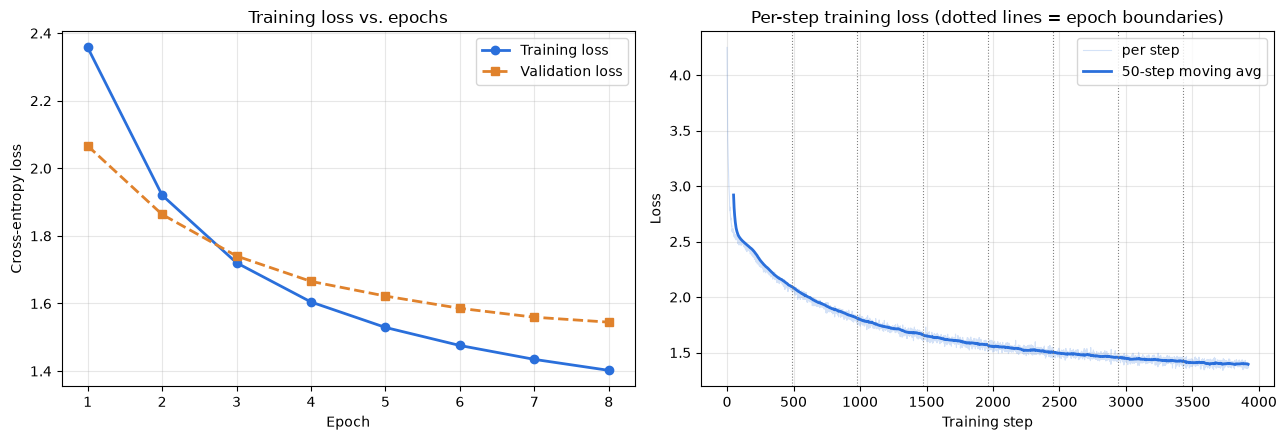

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs = range(1, EPOCHS + 1)
axes[0].plot(epochs, history["train_loss"], "o-", label="Training loss", color="#2a6fdb", lw=2)
axes[0].plot(epochs, history["val_loss"], "s--", label="Validation loss", color="#e0822c", lw=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Training loss vs. epochs")
axes[0].set_xticks(list(epochs)); axes[0].grid(alpha=0.3); axes[0].legend()

# Per-step loss (smoothed) to show the within-epoch trajectory
sl = torch.tensor(history["step_losses"])
w = 50
smooth = sl.unfold(0, w, 1).mean(1)
steps_per_epoch = len(train_loader)
axes[1].plot(sl.numpy(), color="#2a6fdb", alpha=0.2, lw=0.8, label="per step")
axes[1].plot(range(w - 1, len(sl)), smooth.numpy(), color="#2a6fdb", lw=2, label=f"{w}-step moving avg")
for e in range(1, EPOCHS):
    axes[1].axvline(e * steps_per_epoch, color="gray", ls=":", lw=0.8)
axes[1].set_xlabel("Training step"); axes[1].set_ylabel("Loss")
axes[1].set_title("Per-step training loss (dotted lines = epoch boundaries)")
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.savefig("training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 4: Sampling

All three decoders share one autoregressive loop:
1. Feed the current context (cropped to the last 128 tokens) through the model.
2. Take the logits at the **last** position, which give the distribution over the next character.
3. Choose the next token with the decoding rule.
4. Append it and repeat.

| Method | Rule |
|---|---|
| **Greedy** | `argmax(logits)`, always the single most likely character (deterministic) |
| **Temperature** | sample from `softmax(logits / τ)`: τ<1 sharpens the distribution, τ>1 flattens it |
| **Top-k** | keep only the k highest logits, set the rest to −∞, renormalize, then sample |

In [15]:
def greedy_decode(logits: torch.Tensor) -> torch.Tensor:
    """Pick the most likely token."""
    return logits.argmax(dim=-1, keepdim=True)

def temperature_sample(logits: torch.Tensor, temperature: float = 1.0) -> torch.Tensor:
    """Sample from softmax(logits / T)."""
    probs = F.softmax(logits / temperature, dim=-1)
    return torch.multinomial(probs, num_samples=1)

def top_k_sample(logits: torch.Tensor, k: int, temperature: float = 1.0) -> torch.Tensor:
    """Keep only the k most likely tokens, renormalize, and sample."""
    logits = logits / temperature
    kth_value = torch.topk(logits, k, dim=-1).values[..., -1, None]
    logits = logits.masked_fill(logits < kth_value, float("-inf"))
    probs = F.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1)

@torch.no_grad()
def generate(model, prompt: str, max_new_tokens: int, pick_next, seed: int | None = None) -> str:
    """Generic autoregressive generation. `pick_next(logits) -> (B, 1)` token ids."""
    if seed is not None:
        torch.manual_seed(seed)
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.max_len:]         # crop to the context window
        logits, _ = model(idx_cond)
        next_logits = logits[:, -1, :]             # distribution for the next character
        next_id = pick_next(next_logits)
        idx = torch.cat([idx, next_id], dim=1)
    return decode(idx[0].tolist())

PROMPT = "ROMEO:"
N_NEW = 400
GEN_SEED = SEED
samples = {}   # store all outputs for the analysis

### 4.1 Greedy decoding

In [16]:
out = generate(model, PROMPT, N_NEW, greedy_decode)
samples["Greedy"] = out
print(out)

ROMEO:
The present of the princess of the princess.

POMPEY:
I will not so much a strike of the princely of the country.

KING RICHARD III:
The princely of the princess of the prince,
And the present of the present of the prince,
And the present of the princess of the world.

KING RICHARD III:
The present of the princess of the princess.

KING RICHARD III:
The present of the princess of the princely of 


### 4.2 Temperature sampling
Three temperatures chosen to show clearly different behavior:
- **τ = 0.3** (cold): nearly greedy, safe and repetitive
- **τ = 1.0** (neutral): samples from the model's learned distribution unchanged
- **τ = 1.8** (hot): very flat distribution, close to random characters

In [17]:
TEMPERATURES = [0.3, 1.0, 1.8]
for T in TEMPERATURES:
    out = generate(model, PROMPT, N_NEW, lambda l, T=T: temperature_sample(l, T), seed=GEN_SEED)
    samples[f"Temperature τ={T}"] = out
    print(f"==================== Temperature = {T} ====================")
    print(out, "\n")

==================== Temperature = 0.3 ====================
ROMEO:
The king and the present of the body of the fearful of the king.

MENENIUS:
The law may we have been the princely words,
That we we may be the world and all the head.

CORIOLANUS:
I will not be the father's comes of the court?

CORIOLANUS:
He is the proclaim to the world of me?

CORIOLANUS:
Be so, sir, I have been your ancient speak with her
some of me that work that we shall be a more.

CAPULET: 



==================== Temperature = 1.0 ====================
ROMEO:

DUKE VINCENTIO:
You have life, as I may befaect;
And go thy ghost looks power than may in hum.
If With come men my of with comforts,
And with we lady in his spare offence.

SEMN:
It is doubt:
Hark! yet cousin.

WARWICK:
And, but now, I shall be spit and son to our
In encling more marry subjects, than what?

ROMEO:
More, unhoods, as I did not, to them post it.

LUCHIO:
Trong I'll give him. Go, th 



==================== Temperature = 1.8 ====================
ROMEO: traF Bylorow'd speit his; like,
ash; nan hifae, nor hag?
Gon anot-glaced. Gauldera, mad? wert is my reR:
My hang my of ANNEjIol:
Resirous your well.
Now, 'PovPETHMA, he Dpinor to the mark's tragto.
Ho.
Faply:' you
I was life, Tuke moorsal exprept for fools.
Tenco?

ISABELLY:
Will
I swear in Badnist: if York'?

NORFOLK:
Hie how speak we by you,
UsI it: I knully.

GRUMIO,
I finly. I in:--Afp if Jul 



### 4.3 Top-k sampling
Two values of k (both at temperature 1.0):
- **k = 3**: only the 3 most likely characters are allowed, so diversity is low
- **k = 30**: nearly half the vocabulary is allowed, so diversity is high

In [18]:
TOP_KS = [3, 30]
for k in TOP_KS:
    out = generate(model, PROMPT, N_NEW, lambda l, k=k: top_k_sample(l, k), seed=GEN_SEED)
    samples[f"Top-k k={k}"] = out
    print(f"==================== Top-k, k = {k} ====================")
    print(out, "\n")

==================== Top-k, k = 3 ====================
ROMEO:
Traitor, to-dear to the counterfacte of thine
That that we have sent my brother's head;
There is not the poison, and took me whose:
Though thou shalt by the proceed of their court
And so such a provise and with a servant:
If, the should she was the world of the prince,
To brother hearts the was to said of him.

KING RICHARD III:
To see you, and well, and whereon the compassion
And to make him, th 



==================== Top-k, k = 30 ====================
ROMEO:

DUKE VINCENTIO:
You have life, as I may befaect;
And go thy ghost looks power than may in hum.
If With come men my of with comforts,
And with we lady in his spare offence.

SEMN:
It is doubt:
Hark! yet cousin.

WARWICK:
And, but now, I shall be spit and son to our
In encling more marry subjects, than what?

ROMEO:
More, unhoods, as I did not, to them post it.

LUCHIO:
Trong I'll give him. Go, th 



### 4.4 Measuring coherence and diversity
To back up the qualitative comparison we compute simple metrics on longer generations (1,000 characters,
averaged over 3 random seeds):

- **Distinct-2 (words):** unique word bigrams ÷ total word bigrams. Higher means more diverse, less repetition.
- **Repeated 4-grams:** fraction of word 4-grams that appear more than once. Higher means more looping.
- **Real-word rate:** fraction of generated words that also appear in the training text. Higher means more coherent spelling.
- **Model NLL:** average negative log-likelihood per character that the trained model (τ = 1) assigns to the generated
  text. Lower means the text is more "typical" or predictable under the model.

In [19]:
train_vocab_words = set(text.lower().split())

@torch.no_grad()
def text_nll(model, s: str) -> float:
    """Average per-character NLL of string s under the model (sliding windows of max_len)."""
    model.eval()
    ids = torch.tensor(encode(s), dtype=torch.long, device=device)
    total, n = 0.0, 0
    for start in range(0, len(ids) - 1, model.max_len):
        chunk = ids[start : start + model.max_len + 1]
        if len(chunk) < 2:
            break
        logits, _ = model(chunk[:-1][None])
        loss = F.cross_entropy(logits[0], chunk[1:], reduction="sum")
        total += loss.item(); n += len(chunk) - 1
    return total / n

def diversity_metrics(s: str) -> dict:
    words = s.lower().split()
    bigrams = list(zip(words, words[1:]))
    fourgrams = list(zip(*[words[i:] for i in range(4)]))
    c4 = Counter(fourgrams)
    return {
        "distinct2": len(set(bigrams)) / max(1, len(bigrams)),
        "rep4": sum(v for v in c4.values() if v > 1) / max(1, len(fourgrams)),
        "real_word": sum(w.strip(".,;:!?'\"-") in train_vocab_words or
                         w in train_vocab_words for w in words) / max(1, len(words)),
    }

decoders = {"Greedy": greedy_decode}
decoders.update({f"Temperature τ={T}": (lambda l, T=T: temperature_sample(l, T)) for T in TEMPERATURES})
decoders.update({f"Top-k k={k}": (lambda l, k=k: top_k_sample(l, k)) for k in TOP_KS})

metrics = {}
for name, fn in decoders.items():
    seeds = [SEED] if name == "Greedy" else [SEED, SEED + 1, SEED + 2]   # greedy is deterministic
    rows = []
    for s in seeds:
        g = generate(model, PROMPT, 1000, fn, seed=s)[len(PROMPT):]
        m = diversity_metrics(g); m["nll"] = text_nll(model, PROMPT + g)
        rows.append(m)
    metrics[name] = {k: sum(r[k] for r in rows) / len(rows) for k in rows[0]}

print(f"{'Decoder':<20}{'Distinct-2 ↑div':>16}{'Rep. 4-grams':>14}{'Real words':>12}{'Model NLL':>11}")
for name, m in metrics.items():
    print(f"{name:<20}{m['distinct2']:>16.3f}{m['rep4']:>14.3f}{m['real_word']:>12.3f}{m['nll']:>11.3f}")

Decoder              Distinct-2 ↑div  Rep. 4-grams  Real words  Model NLL
Greedy                         0.154         0.939       1.000      0.660
Temperature τ=0.3              0.744         0.065       0.995      0.829
Temperature τ=1.0              0.993         0.000       0.878      1.330
Temperature τ=1.8              1.000         0.000       0.477      2.608
Top-k k=3                      0.936         0.000       0.958      1.018
Top-k k=30                     0.986         0.000       0.911      1.295


In [20]:
# Save results for the written report
with open("results.json", "w") as f:
    json.dump({
        "vocab_size": vocab_size, "n_params": n_params, "d_model": D_MODEL,
        "n_heads": N_HEADS, "n_layers": N_LAYERS, "seq_len": SEQ_LEN,
        "batch_size": BATCH_SIZE, "lr": LR, "epochs": EPOCHS, "stride": STRIDE,
        "steps_per_epoch": len(train_loader),
        "train_loss": history["train_loss"], "val_loss": history["val_loss"],
        "samples": samples, "metrics": metrics,
    }, f, indent=2, ensure_ascii=False)
torch.save(model.state_dict(), "mini_gpt.pt")
print("Saved results.json, training_loss.png, mini_gpt.pt")

Saved results.json, training_loss.png, mini_gpt.pt


## Part 5: Analysis

*(All numbers below come from the metrics table in Section 4.4.)*

**Greedy decoding** always picks the single most likely next character. It is deterministic and has the lowest
model NLL (0.66), since every choice is the model's top choice. Every word it writes is a real word, and it even
formats speaker turns correctly (`POMPEY:`, `KING RICHARD III:`). But it quickly falls into a **loop**, cycling
through *"the present of the princess of the prince..."* again and again. That shows up as the lowest Distinct-2 (0.15) and
94% repeated 4-grams. Greedy search maximizes each step locally and cannot escape a high-probability cycle.

**Temperature sampling** samples from `softmax(logits / τ)`:
- **τ = 0.3:** a sharp distribution. The output is conservative and almost perfectly spelled (99.5% real words), with
  plausible speaker turns (`MENENIUS:`, `CORIOLANUS:`, `CAPULET:`). It breaks out of greedy's loop, though it still
  reuses safe words ("the world", "the princely") and has 6.5% repeated 4-grams.
- **τ = 1.0:** the model's own distribution. The output looks like a varied play (many speakers, different line
  lengths), with some invented words (*"befaect"*, *"encling"*, *"unhoods"*). Distinct-2 is 0.99 and 88% of words are real.
- **τ = 1.8:** a very flat distribution. Rare characters and random capitals appear (*"traF"*, *"ANNEjIol"*, *"'PovPETHMA"*),
  words fall apart, only 48% of words are real, and the NLL (2.61) is far above everything else.

**Top-k sampling** samples only from the k most likely characters:
- **k = 3:** coherent and non-repetitive. 96% real words, no repeated 4-grams, Distinct-2 = 0.94. It reads like
  plausible (if meaningless) verse: *"Traitor, to-dear to the counterfacte of thine / That that we have sent my brother's head"*.
- **k = 30:** almost the same as τ = 1.0. With the same seed, the 400-character sample is actually **identical**, because
  the character that τ = 1.0 sampled was always already in the top 30. With a 65-character vocabulary, the top 30 hold
  nearly all of the probability mass. Over the longer 1,000-character runs, the cutoff helps a little
  (91% vs. 88% real words).

### Which is most coherent?
**Low-temperature sampling (τ = 0.3)**, with **top-k k = 3** a close second. τ = 0.3 has the highest real-word rate
(99.5%), correct play structure, and escapes greedy's loop. Top-k with k = 3 is slightly less accurate (96%) but has
no repetition at all, so it is the better choice if you want coherent **and** varied text. Greedy has the highest
*per-step* likelihood and perfect spelling, but its output as a whole is not coherent, because it repeats the same
phrase over and over.

### Which is most diverse?
**High-temperature sampling (τ = 1.8)**: Distinct-2 = 1.00 with no repeated n-grams, and the most unusual characters
and words. The cost is coherence: fewer than half of its words are real. Among settings that stay readable, τ = 1.0
and top-k with k = 30 are the most diverse.

### Takeaway
Decoding is a **coherence ↔ diversity trade-off**. Greedy decoding and low τ / small k concentrate probability on
likely tokens, which gives coherent text that risks repetition. High τ / large k spread probability out, which gives
diverse text that risks nonsense. Top-k makes the trade-off controllable by cutting off the unreliable tail. With only
65 characters, though, k needs to be small to have a visible effect.